# `transit-strategy` — Spiess & Florian's (1989) optimal strategies

**What.** `transit-strategy` is a transit-assignment model where a passenger
chooses not a single path but a "strategy" — a set of attractive lines to
board whichever comes first — solved as a linear program by a label-setting
pass in decreasing order of expected cost, with frequency-proportional
splitting across the attractive set (common-lines waiting).

**Why it is in the benchmark.** It is the first TRANSIT model — uncongested,
frequency-based, hyperpath assignment, a genuinely different domain from road
UE — and needed its own parallel scenario type (`TransitNetwork`, a directed
multigraph with per-arc in-vehicle time and frequency; parallel arcs allowed
so common lines are direct). See the
[model compendium](../../docs/MODELS.md) (Spiess & Florian 1989) and
[docs/design/adr-014-transit-strategy.md](../../docs/design/adr-014-transit-strategy.md) (P1).

**Scope.** This notebook runs `optimal_strategy` on two built-in common-lines
anchors — one where both lines are attractive, one where a slower line is
excluded — and certifies both against the LP optimum.

**Canon.** `[spiess1989optimal]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `TransitEvaluator` from
the emitted per-arc passenger volumes alone — the harness independently
recomputes the LP optimum `Z*` from the scenario and scores the emitted primal
cost against it; the solver's own labels/costs are never trusted
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `transit-strategy` is a core model: a plain `pip install -e .`
# suffices — no optional extra, so no guard cell. The inline backend is
# Agg-based (headless CI renders into the notebook); NEVER
# matplotlib.use("Agg") in-kernel — it silently suppresses inline capture.
%matplotlib inline
import numpy as np

from tabench import (
    TransitEvaluator,
    common_lines_expected_cost,
    common_lines_scenario,
    common_lines_unattractive_scenario,
    optimal_strategy,
)

## Instance 1: two attractive common lines

One boarding stop (node 0), one destination (node 1), two parallel lines: line
0 (frequency 1/6, in-vehicle 21 min) and line 1 (frequency 1/12, in-vehicle 18
min). `TransitScenario` is frozen and content-hashed (P2), domain-separated
from the road scenario hash space.

In [2]:
scenario = common_lines_scenario(demand=1000.0)
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"lines (freq, time) : "
      f"{list(zip(scenario.network.freq, scenario.network.time))}")
print(f"demand        : {scenario.demand.total}")
print("task          : optimal-strategy hyperpath transit assignment")

scenario      : transit-common-lines
content hash  : 27a419a857b96eab…
lines (freq, time) : [(np.float64(0.16666666666666666), np.float64(21.0)), (np.float64(0.08333333333333333), np.float64(18.0))]
demand        : 1000.0
task          : optimal-strategy hyperpath transit assignment


## Solve

No `Budget`/`RngBundle`/`Trace` — `optimal_strategy` is a pure function of the
scenario (one label-setting + loading pass per destination, deterministic, no
equilibration), emitting a `TransitStrategy` (per-arc passenger volumes, the
P1-certifiable artifact).

In [3]:
strategy = optimal_strategy(scenario)
print(f"arc volumes (line 0, line 1) : {np.round(strategy.arc_volumes, 3)}")
print(f"pair cost (self-reported)    : {strategy.pair_costs}  (provenance only)")

arc volumes (line 0, line 1) : [666.667 333.333]
pair cost (self-reported)    : [24.]  (provenance only)


## Certify (P1) — the LP optimum, recomputed

The harness recomputes the LP-minimal expected cost independently from the
scenario (label-setting, not the model's own labels) and scores
`optimality_gap = (Z_emitted - Z*) / Z*` — zero iff the emitted strategy is
optimal.

In [4]:
evaluator = TransitEvaluator(scenario)
metrics = evaluator.certify(strategy)
print(f"feasible               : {metrics['feasible']:.0f}")
print(f"expected_cost           : {metrics['expected_cost']:.4f}")
print(f"optimality_gap          : {metrics['optimality_gap']:.3e}")
print(f"conservation_residual   : {metrics['conservation_residual']:.3e}")
assert metrics["feasible"] == 1.0
assert metrics["optimality_gap"] < 1e-9
assert np.isclose(metrics["expected_cost"], 24.0, atol=1e-6)  # wait 4 + ride 20

# Recompute the closed form directly from the scenario's own lines, not quoted:
# combined frequency F=1/6+1/12=1/4, C*=(1+sum f*t)/F.
lines = [(1 / 6, 21.0), (1 / 12, 18.0)]
c_star, attractive = common_lines_expected_cost(lines)
print(f"closed-form C*          : {c_star:.6f}  attractive lines: {attractive}")
assert np.isclose(c_star, 24.0, atol=1e-9)
assert attractive == [0, 1]  # both lines attractive

# The frequency-share split: v0/v1 = f0/f1 = 2:1, recomputed from the emitted
# arc volumes directly.
split = strategy.arc_volumes / scenario.demand.total
print(f"demand split (line 0, line 1) : {np.round(split, 4)}  (closed form: 2/3, 1/3)")
np.testing.assert_allclose(split, [2 / 3, 1 / 3], atol=1e-9)

feasible               : 1
expected_cost           : 24.0000
optimality_gap          : 0.000e+00
conservation_residual   : 0.000e+00
closed-form C*          : 24.000000  attractive lines: [0, 1]
demand split (line 0, line 1) : [0.6667 0.3333]  (closed form: 2/3, 1/3)


## Instance 2: the attractiveness threshold

Line 0 alone (frequency 1/6, in-vehicle 15 min) gives an expected cost
`1/(1/6) + 15 = 21` min. Line 1 (frequency 1/12, in-vehicle 40 min) has an
onward cost of 40, NOT below 21 — so it is excluded from the strategy
entirely, and every passenger boards line 0.

In [5]:
scenario2 = common_lines_unattractive_scenario(demand=1000.0)
strategy2 = optimal_strategy(scenario2)
evaluator2 = TransitEvaluator(scenario2)
metrics2 = evaluator2.certify(strategy2)
print(f"feasible        : {metrics2['feasible']:.0f}")
print(f"expected_cost    : {metrics2['expected_cost']:.4f}")
print(f"optimality_gap   : {metrics2['optimality_gap']:.3e}")
assert metrics2["feasible"] == 1.0
assert metrics2["optimality_gap"] < 1e-9
assert np.isclose(metrics2["expected_cost"], 21.0, atol=1e-6)

lines2 = [(1 / 6, 15.0), (1 / 12, 40.0)]
c_star2, attractive2 = common_lines_expected_cost(lines2)
print(f"closed-form C*   : {c_star2:.6f}  attractive lines: {attractive2}")
assert np.isclose(c_star2, 21.0, atol=1e-9)
assert attractive2 == [0]  # line 1 excluded

# All demand on line 0 (line 1 carries zero volume).
print(f"arc volumes (line 0, line 1) : {np.round(strategy2.arc_volumes, 3)}")
np.testing.assert_allclose(strategy2.arc_volumes, [1000.0, 0.0], atol=1e-6)

feasible        : 1
expected_cost    : 21.0000
optimality_gap   : 0.000e+00
closed-form C*   : 21.000000  attractive lines: [0]
arc volumes (line 0, line 1) : [1000.    0.]


## Visualize

`tabench.viz` draws the road `Network`; a transit common-lines scenario is a
`TransitNetwork` (a different scenario type entirely, adr-014), so this
notebook plots the two strategies' frequency-share splits directly.

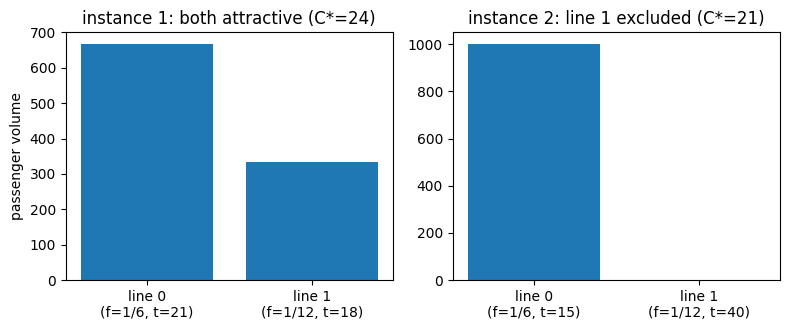

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.4))
axes[0].bar(["line 0\n(f=1/6, t=21)", "line 1\n(f=1/12, t=18)"], strategy.arc_volumes)
axes[0].set_title(f"instance 1: both attractive (C*={metrics['expected_cost']:.0f})")
axes[0].set_ylabel("passenger volume")

axes[1].bar(["line 0\n(f=1/6, t=15)", "line 1\n(f=1/12, t=40)"], strategy2.arc_volumes)
axes[1].set_title(f"instance 2: line 1 excluded (C*={metrics2['expected_cost']:.0f})")
fig.tight_layout()
display(fig)
plt.close(fig)


## Takeaways & pointers

- **Certified, not self-reported.** Both instances' optimal costs came from
  `TransitEvaluator`'s own independent label-setting pass, not the model's
  self-reported labels.
- **The attractiveness threshold is exact.** A line joins the strategy only
  while its onward cost stays below the running expected cost — instance 2
  shows the cut, not just the split.
- **Where next.** the lineage in the [model compendium](../../docs/MODELS.md);
  the parallel-module pattern it shares with the DNL core
  [`ctm`](../05-dnl/01-ctm.ipynb).